In [2]:
import random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray
import pathlib

import loss
import datasets
import models

In [3]:
PATH = '/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'
SCALE_FACTOR = 400

variable = "TM"  # TODO
Y = xarray.open_mfdataset(PATH + variable + "/*.nc", decode_coords="all")

Y = Y[variable]

data_spatial = Y.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
print(data_spatial.rio.bounds())
data = Y.sel(time='2002')
dataset = datasets.ReKIS(Y.sel(time='2002'), SCALE_FACTOR)

(4335000.0, 5554000.0, 4753000.0, 5955000.0)


In [3]:
dataset.Y.shape

torch.Size([365, 1, 400, 400])

In [4]:
torch.random.manual_seed(42)
k = 128
indices = torch.randperm(dataset.Y.shape[0])[:k]

X, Y = dataset.X.reshape((-1, 1, 400//SCALE_FACTOR, 400//SCALE_FACTOR)), dataset.Y.reshape((-1, 1, 400, 400))
X = torch.index_select(X, 0, indices)
Y = torch.index_select(Y, 0, indices)
X.shape, Y.shape

(torch.Size([128, 1, 1, 1]), torch.Size([128, 1, 400, 400]))

In [5]:
Y_bicubic = torch.nn.functional.interpolate(
    X,
    scale_factor=SCALE_FACTOR,
    mode="bicubic",
)

In [6]:
(
    torch.sqrt(torch.mean(torch.square(Y - Y_bicubic))),
    torch.mean(torch.abs(Y - Y_bicubic)),
)

(tensor(1.3631), tensor(1.0305))

In [7]:
CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'

def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
model = models.ConstrainedModel(model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()])), constraint=models.AddConstraintLayer(SCALE_FACTOR))
# model = models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()]))
ckpt = load_checkpoint(107)
checkpoint = torch.load(ckpt, map_location='cuda')
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (loss): LossCombination(
      (losses): ModuleList(
        (0): L1Loss(
          (l1): L1Loss()
        )
      )
    )
    (head): Sequential(
      (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (body): Sequential(
      (0): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(128, 1

In [8]:
Y_edsr = model(X).detach()
torch.sqrt(torch.mean(torch.square(Y_edsr - Y))), torch.mean(torch.abs(Y_edsr - Y))

(tensor(1.1076), tensor(0.8062))

In [19]:
rmses = np.array([torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))) for i in range(len(Y))])
i = np.argmax(rmses)
print(i, rmses[i])

12 2.6893938


tensor(0.8925) tensor(0.7039)


[]

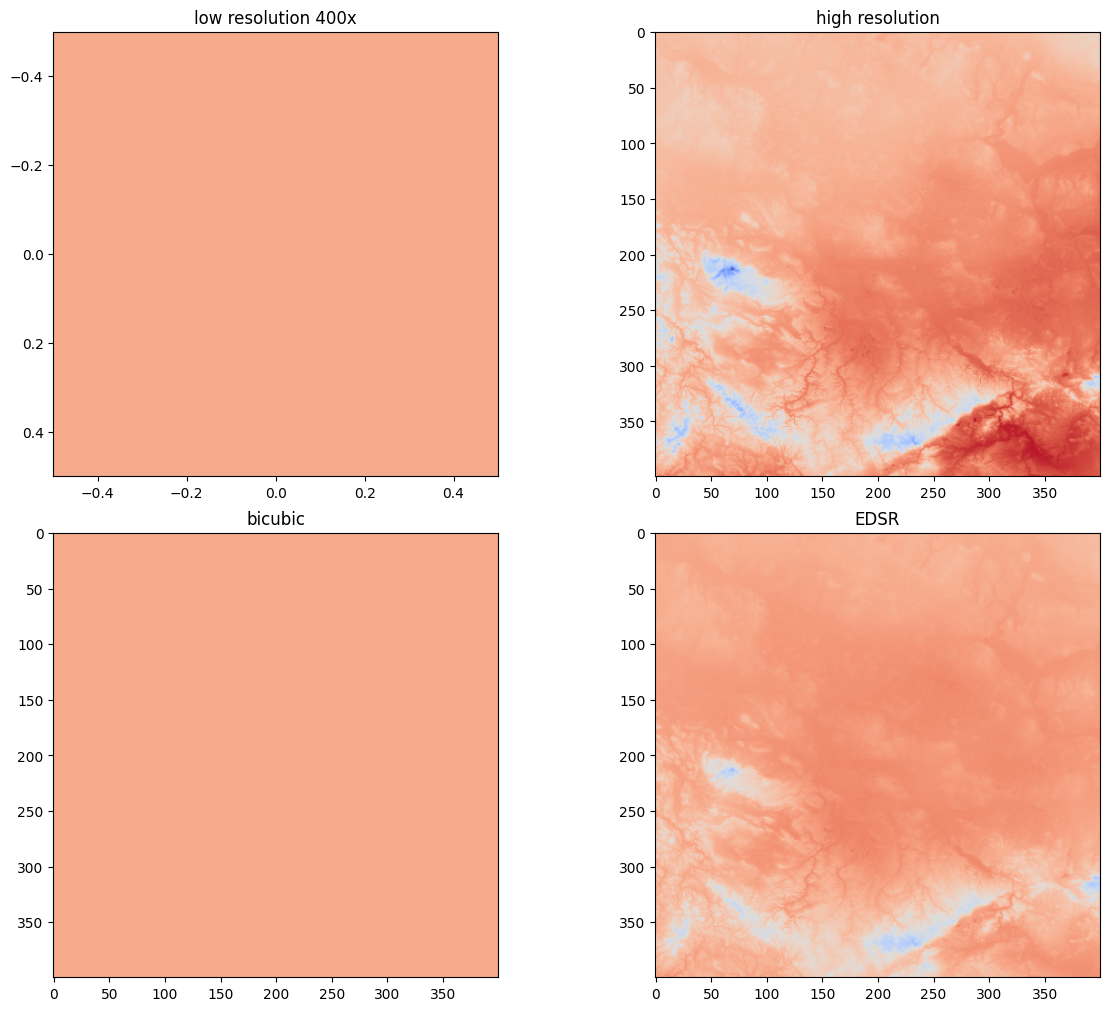

In [25]:
i = random.randint(0, len(Y))
print(torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))), torch.mean(torch.abs(Y_edsr[i] - Y[i])))

fig, axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True, figsize=(12, 10))

cmap_min = min(X[i].min(), Y[i].min(), Y_edsr[i].min(), Y_bicubic[i].min())
cmap_max = max(X[i].max(), Y[i].max(), Y_edsr[i].max(), Y_bicubic[i].max())

axes[0, 0].set_title(f"low resolution {SCALE_FACTOR}x")
axes[0, 0].imshow(X[i], cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[0, 1].set_title("high resolution")
axes[0, 1].imshow(Y[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[1, 0].set_title("bicubic")
axes[1, 0].imshow(Y_bicubic[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[1, 1].set_title("EDSR")
axes[1, 1].imshow(Y_edsr[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

plt.plot()

tensor(0.3939) tensor(0.3076)


TypeError: Invalid shape () for image data

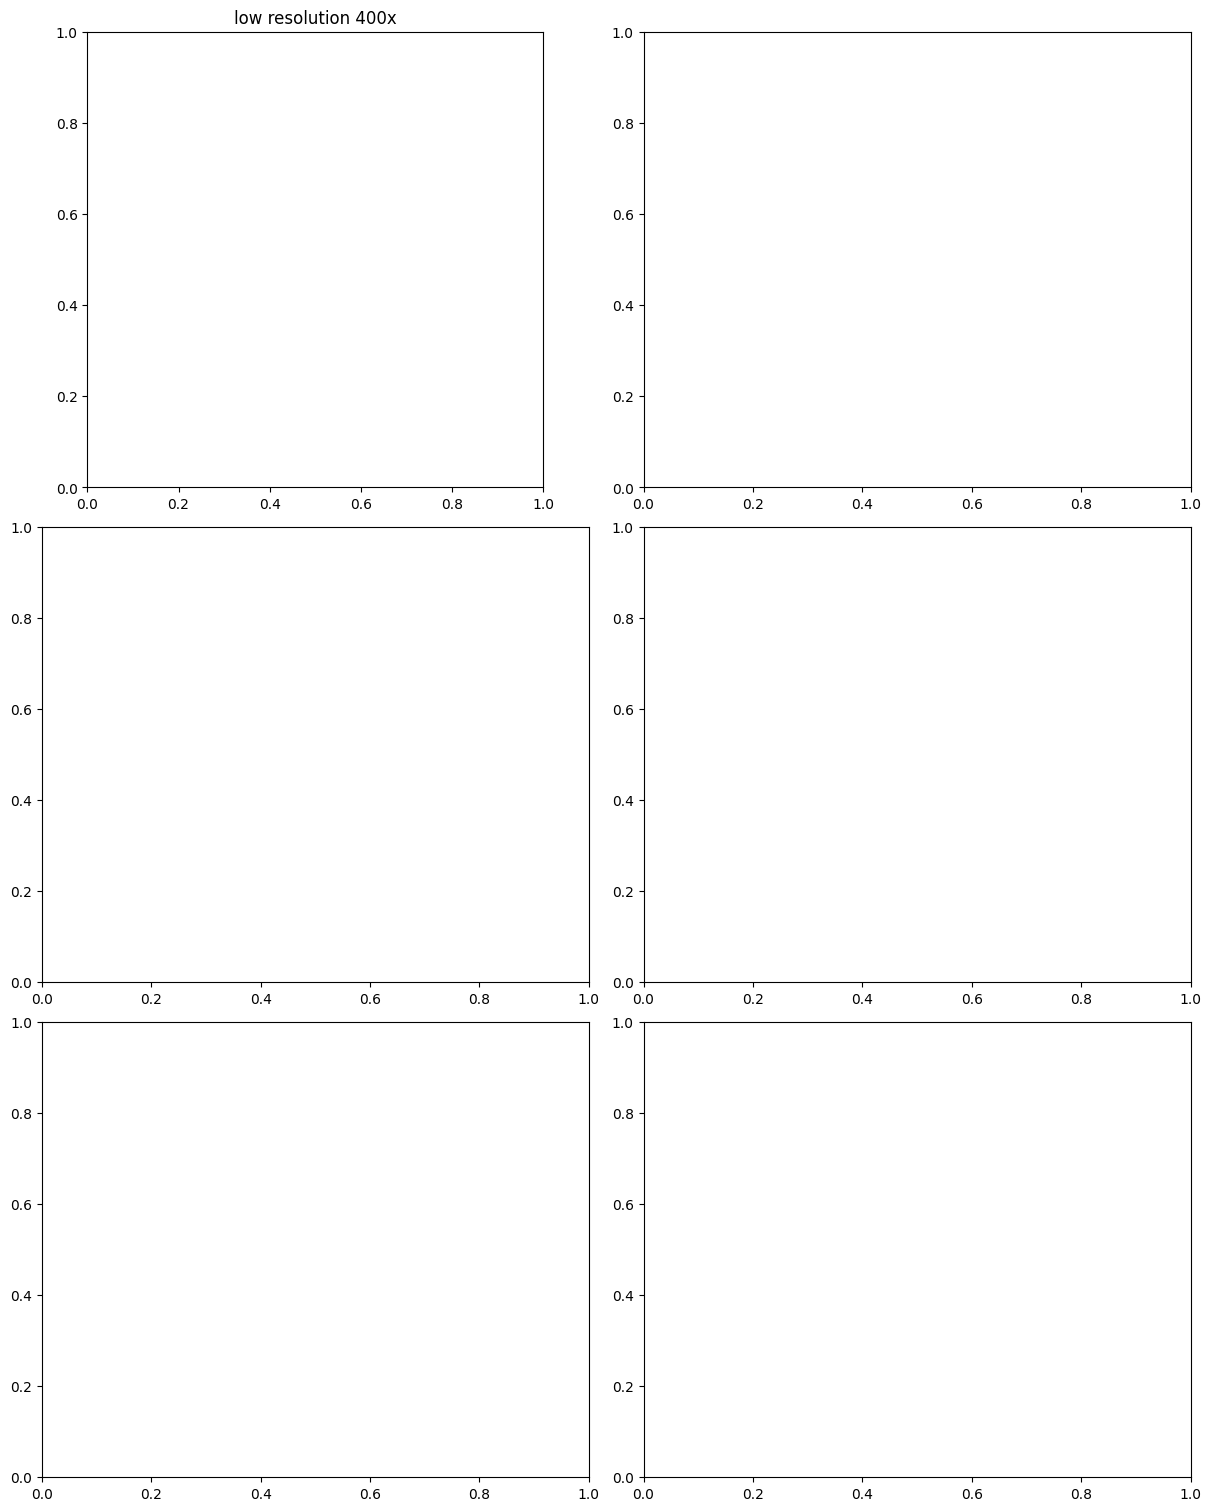

In [13]:
i = random.randint(0, len(Y))
print(torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))), torch.mean(torch.abs(Y_edsr[i] - Y[i])))

fig, axes = plt.subplots(ncols=2, nrows=3, constrained_layout=True, figsize=(12, 15))

cmap_min = min(X[i].min(), Y[i].min(), Y_edsr[i].min(), Y_bicubic[i].min())
cmap_max = max(X[i].max(), Y[i].max(), Y_edsr[i].max(), Y_bicubic[i].max())

axes[0, 0].set_title(f"low resolution {SCALE_FACTOR}x")
axes[0, 0].imshow(X[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[0, 1].set_title("high resolution")
axes[0, 1].imshow(Y[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)


avg = torch.nn.AvgPool2d(200)
X_avg = avg(Y[i])

axes[1, 0].set_title("50x")
axes[1, 0].imshow(X_avg.squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[1, 1].set_title("EDSR")
axes[1, 1].imshow(Y_edsr[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

axes[2, 0].set_title("bicubic")
axes[2, 0].imshow(Y_bicubic[i].squeeze(), cmap="coolwarm", vmin=cmap_min, vmax=cmap_max)

plt.plot()

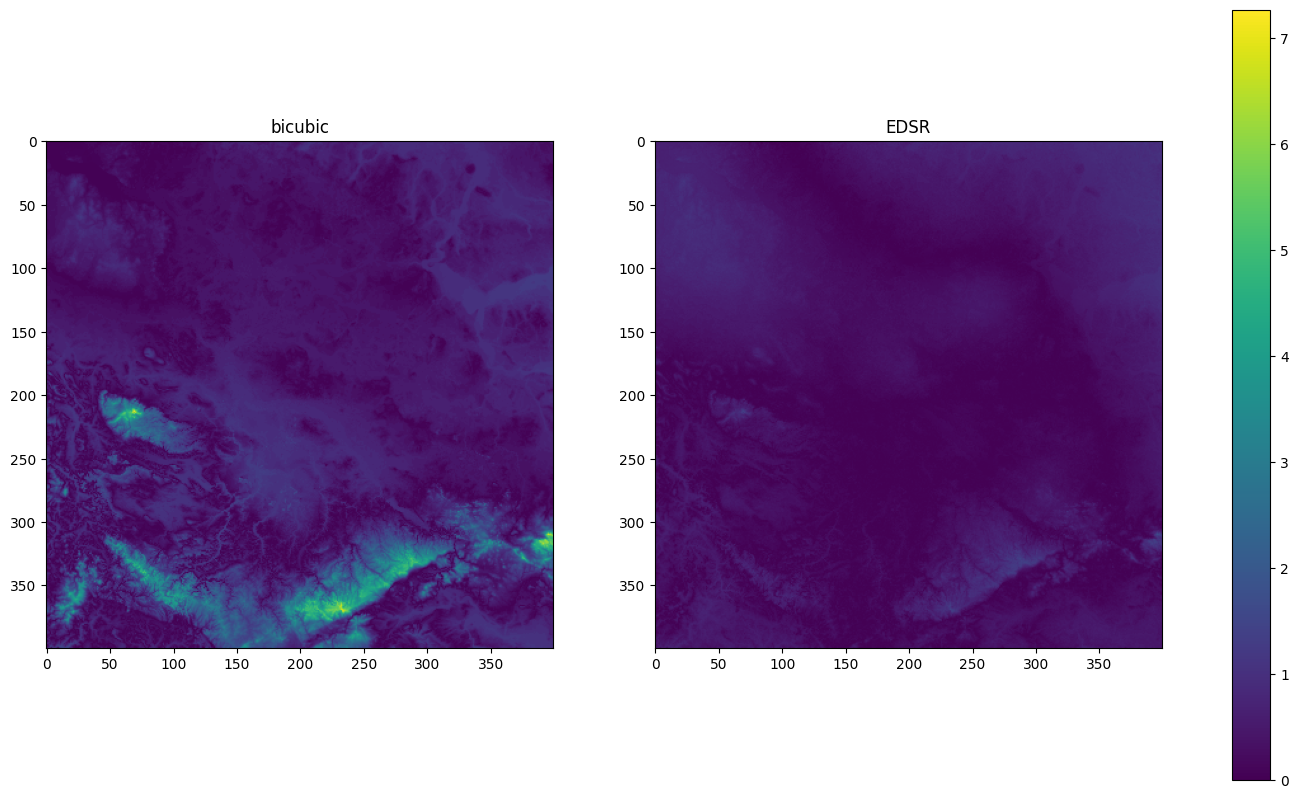

In [14]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 10))
error_bicubic = abs(Y[i] - Y_bicubic[i])
error_edsr = abs(Y[i] - Y_edsr[i])
maximum = max(torch.max(error_bicubic), torch.max(error_edsr))
norm = matplotlib.colors.Normalize(vmin=0, vmax=maximum)
axes[0].set_title("bicubic")
im = axes[0].imshow(error_bicubic.squeeze(), norm=norm)
axes[1].set_title("EDSR")
axes[1].imshow(error_edsr.squeeze(), norm=norm)
fig.colorbar(im, ax=axes)

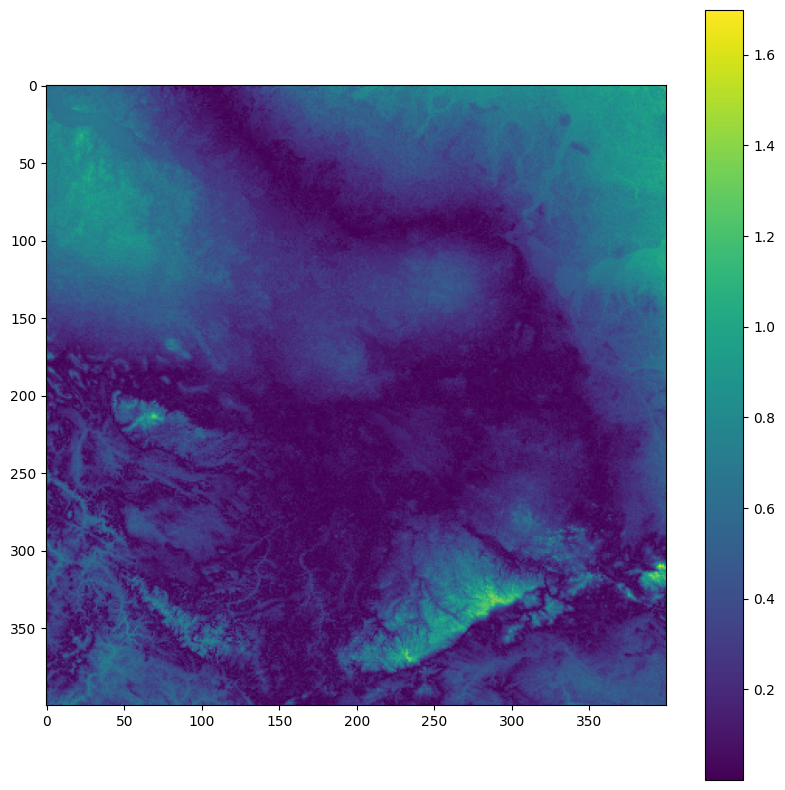

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(error_edsr.squeeze())
fig.colorbar(im)

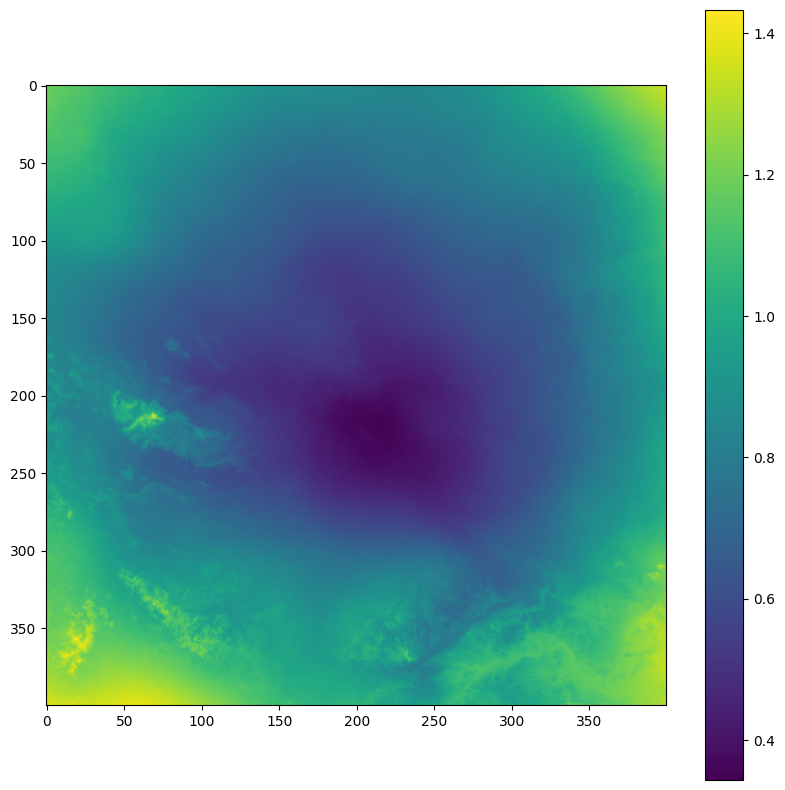

In [16]:
error_edsr = (Y_edsr - Y).abs().mean(dim=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(error_edsr.squeeze())
fig.colorbar(im)